In [1]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from tqdm import tqdm
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler
from matplotlib.animation import FuncAnimation, PillowWriter
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools
from statsmodels.tsa.arima.model import ARIMA

### Create DF's

In [2]:
# Get temp dfs
df_temp_nsw = pd.read_csv(r'data\NSW\extracted_files\temperature_nsw.csv')

# Get Demands dfs
df_demand_nsw = pd.read_csv(r'data\NSW\extracted_files\totaldemand_nsw.csv')

#get forecast df
df_forecast_nsw = pd.read_csv(r'data\NSW\extracted_files\forecastdemand_nsw.csv')


### Initial Preporcessing

In [3]:
df_temp_nsw_copy = df_temp_nsw.copy()
df_demand_nsw_copy = df_demand_nsw.copy()
df_forecast_nsw_copy = df_forecast_nsw.copy()

In [4]:
# Convert 'DATETIME' column with day-first format
df_temp_nsw_copy['DATETIME'] = pd.to_datetime(df_temp_nsw_copy['DATETIME'], dayfirst=True)
df_demand_nsw_copy['DATETIME'] = pd.to_datetime(df_demand_nsw_copy['DATETIME'], dayfirst=True)
df_forecast_nsw_copy['DATETIME'] = pd.to_datetime(df_forecast_nsw_copy['DATETIME'], dayfirst=True, format='mixed')
df_forecast_nsw_copy['LASTCHANGED'] = pd.to_datetime(df_forecast_nsw_copy['LASTCHANGED'], dayfirst=True, format='mixed')

### Combine demand and Temp

In [5]:
df_nsw_merge_temp_demand = pd.merge(df_temp_nsw_copy, df_demand_nsw_copy, on='DATETIME', how='inner')

In [6]:
df_nsw_merge_temp_demand

,LOCATION,DATETIME,TEMPERATURE,TOTALDEMAND,REGIONID
0,Bankstown,2010-01-01 00:00:00,23.1,8038.00,NSW1
1,Bankstown,2010-01-01 00:30:00,22.9,7809.31,NSW1
2,Bankstown,2010-01-01 01:00:00,22.6,7483.69,NSW1
3,Bankstown,2010-01-01 01:30:00,22.5,7117.23,NSW1
4,Bankstown,2010-01-01 02:00:00,22.5,6812.03,NSW1
...,...,...,...,...,...
195942,Bankstown,2021-03-17 22:00:00,19.7,7419.77,NSW1
195943,Bankstown,2021-03-17 22:30:00,19.5,7417.91,NSW1
195944,Bankstown,2021-03-17 23:00:00,19.1,7287.32,NSW1
195945,Bankstown,2021-03-17 23:30:00,18.8,7172.39,NSW1


In [7]:
df_nsw_merge_temp_demand_forecast = pd.merge(df_nsw_merge_temp_demand,df_forecast_nsw_copy[df_forecast_nsw_copy['PERIODID'] == 71],on='DATETIME', how='inner')

In [8]:
df = df_nsw_merge_temp_demand_forecast 
# Sort the data by DATETIME just to be sure
df = df.sort_values(by='DATETIME')

# Set DATETIME as the index for convenience (not strictly necessary)
df.set_index('DATETIME', inplace=True)

# Define the dependent variable (electricity demand)
y = df['TOTALDEMAND']

# Define the exogenous variables (temperature and forecast demand)
exog = df[['TEMPERATURE', 'FORECASTDEMAND']]


# Arima Model

0it [00:00, ?it/s]c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
1it [00:00,  3.35it/s]c:\Users\

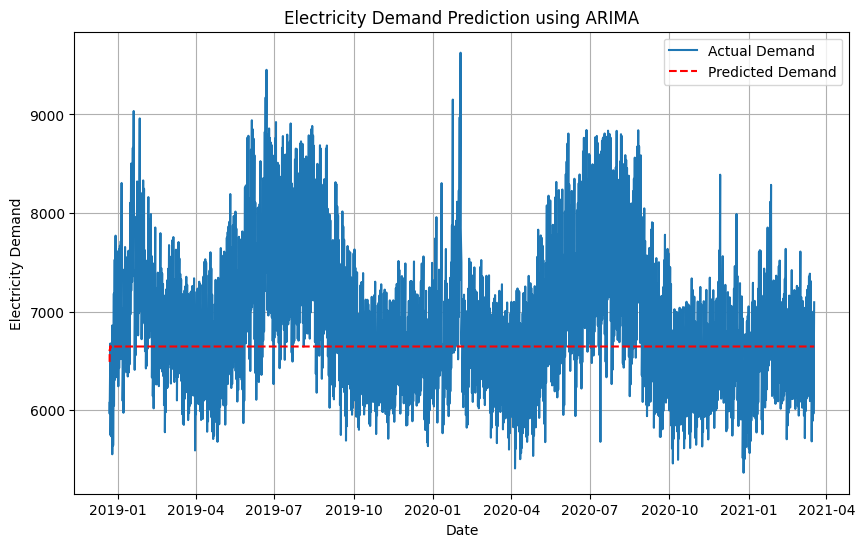

Best ARIMA Parameters: (2, 1, 2)
Mean Squared Error (MSE): 513013.3669342075
Mean Absolute Error (MAE): 562.3226624976195


In [9]:
# # Split the data into training and test sets (80% train, 20% test)
# train_size = int(len(df) * 0.8)
# y_train, y_test = y[:train_size], y[train_size:]

# # Function to optimize ARIMA hyperparameters using grid search
# def optimize_arima(train, p_values, d_values, q_values):
#     best_aic = np.inf
#     best_params = None
#     best_model = None
    
#     for p, d, q in tqdm(itertools.product(p_values, d_values, q_values)):
#         try:
#             model = ARIMA(train, order=(p, d, q))
#             model_fit = model.fit()
#             if model_fit.aic < best_aic:
#                 best_aic = model_fit.aic
#                 best_params = (p, d, q)
#                 best_model = model_fit
#         except Exception as e:
#             continue
    
#     return best_params, best_model

# # Define hyperparameter grid for ARIMA
# p_values = [0, 1, 2]
# d_values = [0, 1]
# q_values = [0, 1, 2]

# # Run the optimization to find the best ARIMA model
# best_params, best_model = optimize_arima(y_train, p_values, d_values, q_values)

# # Make predictions on the test set
# predictions = best_model.forecast(steps=len(y_test))

# # Calculate performance metrics
# mse = mean_squared_error(y_test, predictions)
# mae = mean_absolute_error(y_test, predictions)

# # Plot the predictions vs actual demand
# plt.figure(figsize=(10, 6))
# plt.plot(y_test.index, y_test, label='Actual Demand')
# plt.plot(y_test.index, predictions, label='Predicted Demand', linestyle='--', color='red')
# plt.title('Electricity Demand Prediction using ARIMA')
# plt.xlabel('Date')
# plt.ylabel('Electricity Demand')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Display performance metrics and best ARIMA parameters
# print(f'Best ARIMA Parameters: {best_params}')
# print(f'Mean Squared Error (MSE): {mse}')
# print(f'Mean Absolute Error (MAE): {mae}')

# Arimax Model - Temperature

c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Ca

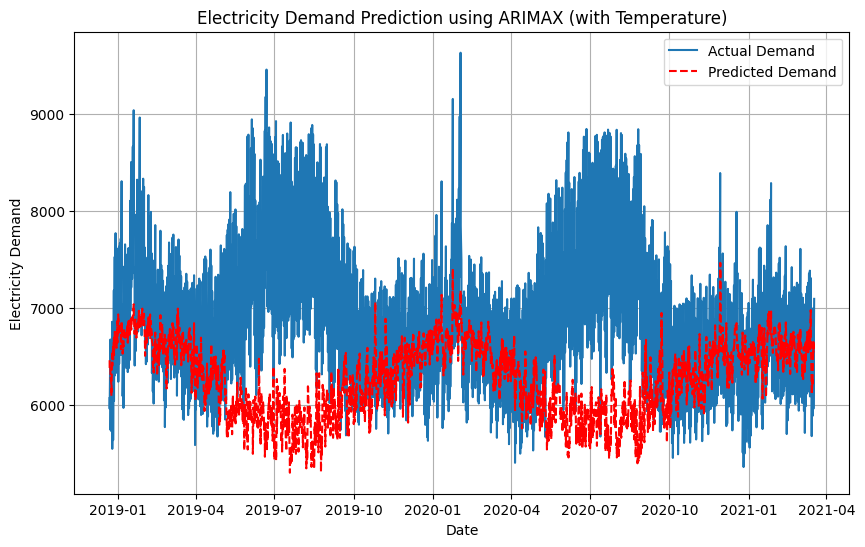

Best ARIMAX Parameters: (2, 1, 2)
Mean Squared Error (MSE): 1078555.3320342447
Mean Absolute Error (MAE): 760.4262373774346


In [10]:
# # Use the DataFrame you've provided: df_nsw_merge_temp_demand_forecast
# df = df_nsw_merge_temp_demand_forecast

# # Sort the data by DATETIME to ensure proper ordering
# df = df.sort_values(by='DATETIME')

# # Set DATETIME as the index
# df.set_index('DATETIME', inplace=True)

# # Define the dependent variable (electricity demand)
# y = df['TOTALDEMAND']

# # Define the exogenous variable (temperature)
# exog = df[['TEMPERATURE']]  # Only using TEMPERATURE as exogenous variable

# # Split the data into training and test sets (80% train, 20% test)
# train_size = int(len(df) * 0.8)
# y_train, y_test = y[:train_size], y[train_size:]
# exog_train, exog_test = exog[:train_size], exog[train_size:]

# # Function to optimize ARIMAX hyperparameters using grid search with exogenous variables
# def optimize_arimax(train, exog_train, p_values, d_values, q_values):
#     best_aic = np.inf
#     best_params = None
#     best_model = None
    
#     for p, d, q in itertools.product(p_values, d_values, q_values):
#         try:
#             model = SARIMAX(train, exog=exog_train, order=(p, d, q))
#             model_fit = model.fit(disp=False)
#             if model_fit.aic < best_aic:
#                 best_aic = model_fit.aic
#                 best_params = (p, d, q)
#                 best_model = model_fit
#         except Exception as e:
#             continue
    
#     return best_params, best_model

# # Define hyperparameter grid for ARIMAX
# p_values = [0, 1, 2]
# d_values = [0, 1]
# q_values = [0, 1, 2]

# # Run the optimization to find the best ARIMAX model
# best_params, best_model = optimize_arimax(y_train, exog_train, p_values, d_values, q_values)

# # Make predictions on the test set using the exogenous variable (temperature)
# predictions = best_model.forecast(steps=len(y_test), exog=exog_test)

# # Calculate performance metrics
# mse = mean_squared_error(y_test, predictions)
# mae = mean_absolute_error(y_test, predictions)

# # Plot the predictions vs actual demand
# plt.figure(figsize=(10, 6))
# plt.plot(y_test.index, y_test, label='Actual Demand')
# plt.plot(y_test.index, predictions, label='Predicted Demand', linestyle='--', color='red')
# plt.title('Electricity Demand Prediction using ARIMAX (with Temperature)')
# plt.xlabel('Date')
# plt.ylabel('Electricity Demand')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Display performance metrics and best ARIMAX parameters
# print(f'Best ARIMAX Parameters: {best_params}')
# print(f'Mean Squared Error (MSE): {mse}')
# print(f'Mean Absolute Error (MAE): {mae}')

# Arimax - Temperaure and Forecasted Demand

c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Ca

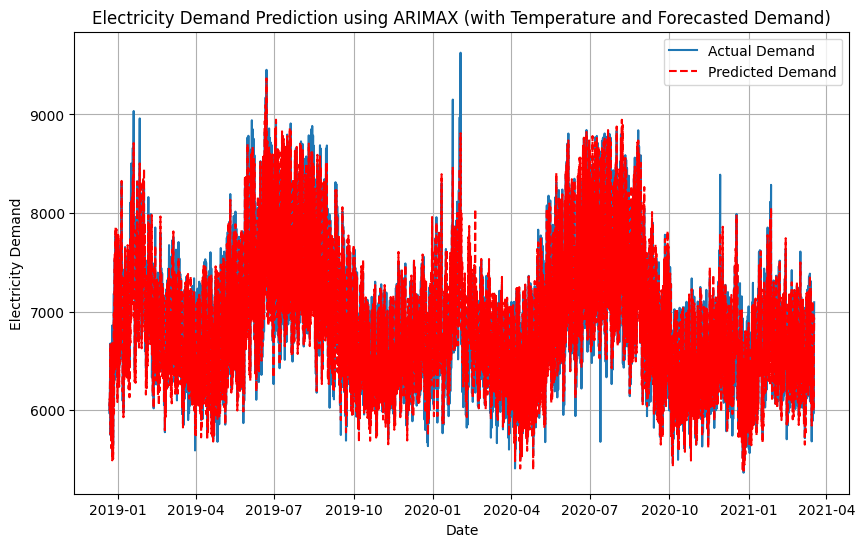

Best ARIMAX Parameters: (2, 1, 2)
Mean Squared Error (MSE): 21579.06650977172
Mean Absolute Error (MAE): 109.43115313804218


In [11]:
# # Use the DataFrame you've provided: df_nsw_merge_temp_demand_forecast
# df = df_nsw_merge_temp_demand_forecast

# # Sort the data by DATETIME to ensure proper ordering
# df = df.sort_values(by='DATETIME')

# # Set DATETIME as the index
# df.set_index('DATETIME', inplace=True)

# # Define the dependent variable (electricity demand)
# y = df['TOTALDEMAND']

# # Define the exogenous variables (temperature and forecasted demand)
# exog = df[['TEMPERATURE', 'FORECASTDEMAND']]  # Use both TEMPERATURE and FORECASTDEMAND

# # Split the data into training and test sets (80% train, 20% test)
# train_size = int(len(df) * 0.8)
# y_train, y_test = y[:train_size], y[train_size:]
# exog_train, exog_test = exog[:train_size], exog[train_size:]

# # Function to optimize ARIMAX hyperparameters using grid search with exogenous variables
# def optimize_arimax(train, exog_train, p_values, d_values, q_values):
#     best_aic = np.inf
#     best_params = None
#     best_model = None
    
#     for p, d, q in itertools.product(p_values, d_values, q_values):
#         try:
#             model = SARIMAX(train, exog=exog_train, order=(p, d, q))
#             model_fit = model.fit(disp=False)
#             if model_fit.aic < best_aic:
#                 best_aic = model_fit.aic
#                 best_params = (p, d, q)
#                 best_model = model_fit
#         except Exception as e:
#             continue
    
#     return best_params, best_model

# # Define hyperparameter grid for ARIMAX
# p_values = [0, 1, 2]
# d_values = [0, 1]
# q_values = [0, 1, 2]

# # Run the optimization to find the best ARIMAX model
# best_params, best_model = optimize_arimax(y_train, exog_train, p_values, d_values, q_values)

# # Make predictions on the test set using the exogenous variables (temperature and forecasted demand)
# predictions = best_model.forecast(steps=len(y_test), exog=exog_test)

# # Calculate performance metrics
# mse = mean_squared_error(y_test, predictions)
# mae = mean_absolute_error(y_test, predictions)

# # Plot the predictions vs actual demand
# plt.figure(figsize=(10, 6))
# plt.plot(y_test.index, y_test, label='Actual Demand')
# plt.plot(y_test.index, predictions, label='Predicted Demand', linestyle='--', color='red')
# plt.title('Electricity Demand Prediction using ARIMAX (with Temperature and Forecasted Demand)')
# plt.xlabel('Date')
# plt.ylabel('Electricity Demand')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Display performance metrics and best ARIMAX parameters
# print(f'Best ARIMAX Parameters: {best_params}')
# print(f'Mean Squared Error (MSE): {mse}')
# print(f'Mean Absolute Error (MAE): {mae}')

# SarimaX Model

c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Ca

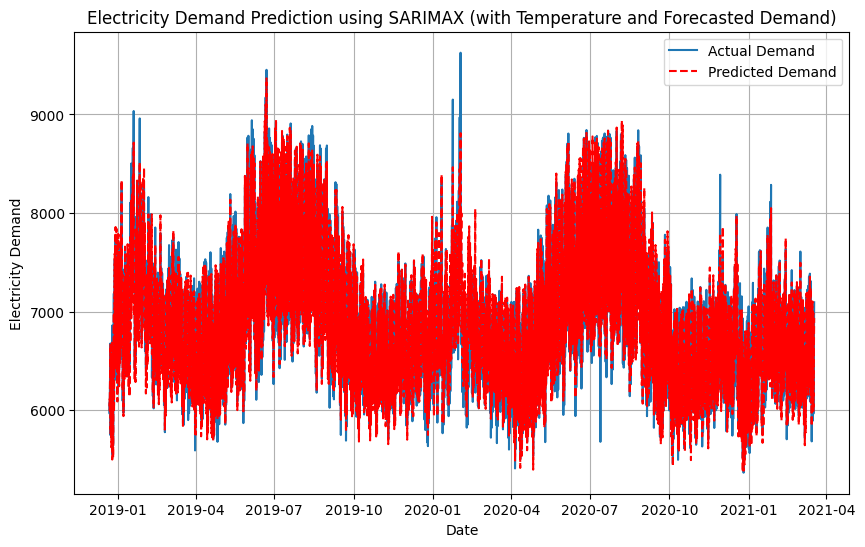

Best SARIMAX Parameters: (2, 1, 1, 0, 1, 1, 24)
Mean Squared Error (MSE): 21482.35309201449
Mean Absolute Error (MAE): 109.15546666200619


In [12]:
# # Use the DataFrame you've provided: df_nsw_merge_temp_demand_forecast
# df = df_nsw_merge_temp_demand_forecast

# # Sort the data by DATETIME to ensure proper ordering
# df = df.sort_values(by='DATETIME')

# # Set DATETIME as the index
# df.set_index('DATETIME', inplace=True)

# # Define the dependent variable (electricity demand)
# y = df['TOTALDEMAND']

# # Define the exogenous variables (temperature and forecasted demand)
# exog = df[['TEMPERATURE', 'FORECASTDEMAND']]  # Using both TEMPERATURE and FORECASTDEMAND

# # Split the data into training and test sets (80% train, 20% test)
# train_size = int(len(df) * 0.8)
# y_train, y_test = y[:train_size], y[train_size:]
# exog_train, exog_test = exog[:train_size], exog[train_size:]

# # Function to optimize SARIMAX hyperparameters using grid search with exogenous variables
# def optimize_sarimax(train, exog_train, p_values, d_values, q_values, P_values, D_values, Q_values, m_values):
#     best_aic = np.inf
#     best_params = None
#     best_model = None
    
#     for (p, d, q), (P, D, Q, m) in itertools.product(itertools.product(p_values, d_values, q_values),
#                                                       itertools.product(P_values, D_values, Q_values, m_values)):
#         try:
#             model = SARIMAX(train, exog=exog_train, order=(p, d, q), seasonal_order=(P, D, Q, m))
#             model_fit = model.fit(disp=False)
#             if model_fit.aic < best_aic:
#                 best_aic = model_fit.aic
#                 best_params = (p, d, q, P, D, Q, m)
#                 best_model = model_fit
#         except Exception as e:
#             continue
    
#     return best_params, best_model

# # Define hyperparameter grid for SARIMAX
# p_values = [0, 1, 2]
# d_values = [0, 1]
# q_values = [0, 1, 2]
# P_values = [0, 1]  # Seasonal AR term
# D_values = [0, 1]  # Seasonal differencing term
# Q_values = [0, 1]  # Seasonal MA term
# m_values = [24]    # Assuming daily seasonality for hourly data (24 hours per day)

# # Run the optimization to find the best SARIMAX model
# best_params, best_model = optimize_sarimax(y_train, exog_train, p_values, d_values, q_values, P_values, D_values, Q_values, m_values)

# # Make predictions on the test set using the exogenous variables (temperature and forecasted demand)
# predictions = best_model.forecast(steps=len(y_test), exog=exog_test)

# # Calculate performance metrics
# mse = mean_squared_error(y_test, predictions)
# mae = mean_absolute_error(y_test, predictions)

# # Plot the predictions vs actual demand
# plt.figure(figsize=(10, 6))
# plt.plot(y_test.index, y_test, label='Actual Demand')
# plt.plot(y_test.index, predictions, label='Predicted Demand', linestyle='--', color='red')
# plt.title('Electricity Demand Prediction using SARIMAX (with Temperature and Forecasted Demand)')
# plt.xlabel('Date')
# plt.ylabel('Electricity Demand')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Display performance metrics and best SARIMAX parameters
# print(f'Best SARIMAX Parameters: {best_params}')
# print(f'Mean Squared Error (MSE): {mse}')
# print(f'Mean Absolute Error (MAE): {mae}')

# lstm Model

Epoch 1/10
919/919 [==============================] - 20s 18ms/step - loss: 0.0078
Epoch 2/10
919/919 [==============================] - 17s 18ms/step - loss: 0.0041
Epoch 3/10
919/919 [==============================] - 16s 18ms/step - loss: 0.0028
Epoch 4/10
919/919 [==============================] - 18s 19ms/step - loss: 0.0022
Epoch 5/10
919/919 [==============================] - 18s 20ms/step - loss: 0.0019
Epoch 6/10
919/919 [==============================] - 18s 20ms/step - loss: 0.0017
Epoch 7/10
919/919 [==============================] - 16s 18ms/step - loss: 0.0017
Epoch 8/10
919/919 [==============================] - 16s 17ms/step - loss: 0.0016
Epoch 9/10
919/919 [==============================] - 17s 18ms/step - loss: 0.0015
Epoch 10/10
230/230 [==============================] - 2s 6ms/step
Mean Absolute Error (MAE): 129.1823429708773
Mean Squared Error (MSE): 31003.164516108332
Root Mean Squared Error (RMSE): 176.07715500912755


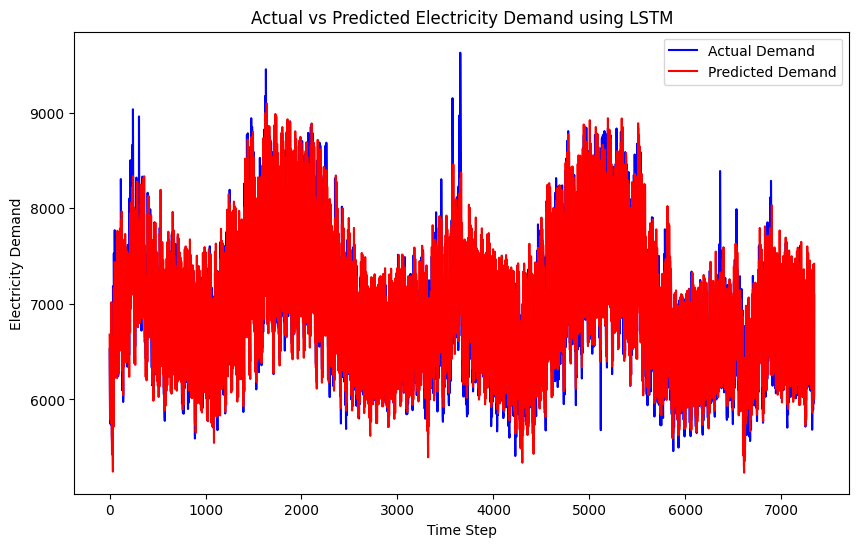

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import holidays  # For marking holidays

# Load your dataset (assuming your dataset is in a pandas DataFrame)
df = df_nsw_merge_temp_demand_forecast

# Step 1: Sort the data by DATETIME and set it as index
df['DATETIME'] = pd.to_datetime(df['DATETIME'])
df = df.sort_values(by='DATETIME')
df.set_index('DATETIME', inplace=True)

# Step 2: Create time-based features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

# Step 3: Mark public holidays using the 'holidays' package (assuming Australian holidays for NSW)
years = df.index.year.unique()
au_holidays = holidays.Australia(years=years)
df['is_holiday'] = df.index.map(lambda x: 1 if x in au_holidays else 0)

# Step 4: Select relevant features and the target variable
features = ['TEMPERATURE', 'FORECASTDEMAND', 'hour', 'day_of_week', 'month', 'is_holiday']
target = 'TOTALDEMAND'

# Step 5: Normalize the features and target separately
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

# Normalize the features
df[features] = scaler_features.fit_transform(df[features])

# Normalize the target
df[target] = scaler_target.fit_transform(df[[target]])

# Step 6: Create sequences for LSTM input (look at the past 24 hours to predict the next hour)
def create_sequences(data, sequence_length):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, :-1])  # Use all columns except the target for X
        y.append(data[i, -1])  # Target is the last column (TOTALDEMAND)
    return np.array(X), np.array(y)

# Convert the dataframe to a NumPy array for creating sequences
data = df[features + [target]].values

# Set the sequence length (e.g., 24 time steps = past 24 hours of data)
sequence_length = 24

# Create sequences for the LSTM
X, y = create_sequences(data, sequence_length)

# Step 7: Train-test split (e.g., 80% train, 20% test)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Step 8: Build the LSTM model
model = Sequential()

# First LSTM layer with Dropout regularization
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  # Dropout to prevent overfitting

# Second LSTM layer with Dropout regularization
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))  # Output layer to predict TOTALDEMAND

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 9: Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Step 10: Make predictions on the test set
y_pred = model.predict(X_test)

# Step 11: Rescale the predictions and the actual values back to their original scale using the target scaler
y_pred_rescaled = scaler_target.inverse_transform(y_pred)
y_test_rescaled = scaler_target.inverse_transform(y_test.reshape(-1, 1))

# Step 12: Evaluate the model
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

# Step 13: Plot the actual vs predicted demand
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label='Actual Demand', color='blue')
plt.plot(y_pred_rescaled, label='Predicted Demand', color='red')
plt.xlabel('Time Step')
plt.ylabel('Electricity Demand')
plt.title('Actual vs Predicted Electricity Demand using LSTM')
plt.legend()
plt.show()


# LSTM - More Advanced

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load your dataset (assuming your dataset is in a pandas DataFrame)
df = df_nsw_merge_temp_demand_forecast

# Step 1: Sort the data by DATETIME and set it as index
df['DATETIME'] = pd.to_datetime(df['DATETIME'])
df = df.sort_values(by='DATETIME')
df.set_index('DATETIME', inplace=True)

# Step 2: Create time-based features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

# Step 3: Select relevant features and the target variable
features = ['TEMPERATURE', 'FORECASTDEMAND', 'hour', 'day_of_week', 'month']
target = 'TOTALDEMAND'

# Step 4: Normalize the features and target separately
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

# Normalize the features
df[features] = scaler_features.fit_transform(df[features])

# Normalize the target
df[target] = scaler_target.fit_transform(df[[target]])

# Step 5: Function to create sequences for LSTM input
def create_sequences(data, sequence_length):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, :-1])  # Use all columns except the target for X
        y.append(data[i, -1])  # Target is the last column (TOTALDEMAND)
    return np.array(X), np.array(y)

# Step 6: Function to build and train the LSTM model
def build_and_train_model(X_train, y_train, sequence_length):
    model = Sequential()
    # First LSTM layer with Dropout regularization
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))

    # Second LSTM layer with Dropout regularization
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))

    # Output layer
    model.add(Dense(1))  # Predicting TOTALDEMAND

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    model.fit(X_train, y_train, epochs=7, batch_size=32, verbose=1)
    return model

# Step 7: Experiment with different sequence lengths and record results
sequence_lengths = [168]  # Different sequence lengths to test (daily, 2 days, weekly)
results = []

for sequence_length in sequence_lengths:
    # Convert the dataframe to a NumPy array for creating sequences
    data = df[features + [target]].values
    
    # Create sequences for the LSTM
    X, y = create_sequences(data, sequence_length)

    # Train-test split (e.g., 80% train, 20% test)
    train_size = int(0.8 * len(X))
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Build and train the LSTM model
    model = build_and_train_model(X_train, y_train, sequence_length)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Rescale the predictions and the actual values back to their original scale using the target scaler
    y_pred_rescaled = scaler_target.inverse_transform(y_pred)
    y_test_rescaled = scaler_target.inverse_transform(y_test.reshape(-1, 1))

    # Evaluate the model
    mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
    mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
    rmse = np.sqrt(mse)

    # Record the results for the current sequence length
    results.append({
        'sequence_length': sequence_length,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    })

    # Print the results
    print(f"Results for Sequence Length = {sequence_length}:")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print("-" * 50)

# Step 8: Plotting the results for each sequence length
sequence_lengths = [result['sequence_length'] for result in results]
rmse_values = [result['RMSE'] for result in results]

plt.figure(figsize=(10, 6))
plt.plot(sequence_lengths, rmse_values, marker='o')
plt.title('RMSE for Different Sequence Lengths')
plt.xlabel('Sequence Length (Hours)')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()


Epoch 1/7
397/915 [============>.................] - ETA: 1:04 - loss: 0.0118

KeyboardInterrupt: 

# Rolling Window + Exponential Smoothing

Fitting model with window size: 24


c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837

Results for window size 24:
Mean Absolute Error (MAE): 3527.4677631395357
Mean Squared Error (MSE): 17413111.429110814
Root Mean Squared Error (RMSE): 4172.9020392420925
--------------------------------------------------
Fitting model with window size: 48


c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837

Results for window size 48:
Mean Absolute Error (MAE): 827.6041111854092
Mean Squared Error (MSE): 1005179.2184330651
Root Mean Squared Error (RMSE): 1002.5862648336376
--------------------------------------------------
Fitting model with window size: 168


c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\OneDrive\Desktop\University\UNSW\Capstone Project - ZZSC9020\project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837

Results for window size 168:
Mean Absolute Error (MAE): 7224.674147301553
Mean Squared Error (MSE): 71625956.20807892
Root Mean Squared Error (RMSE): 8463.211932125942
--------------------------------------------------


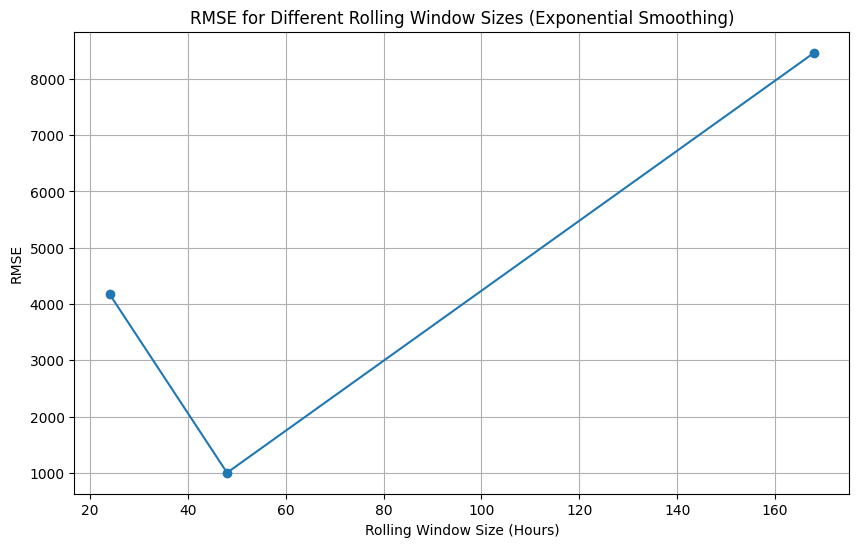

   window_size          MAE           MSE         RMSE
0           24  3527.467763  1.741311e+07  4172.902039
1           48   827.604111  1.005179e+06  1002.586265
2          168  7224.674147  7.162596e+07  8463.211932


In [15]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Assuming df_nsw_merge_temp_demand_forecast is already loaded as df
df = df_nsw_merge_temp_demand_forecast

# Sort the data by DATETIME just to be sure
df = df.sort_values(by='DATETIME')

# Set DATETIME as the index
df.set_index('DATETIME', inplace=True)

# Define the dependent variable (electricity demand)
y = df['TOTALDEMAND']

# Define the exogenous variables (temperature and forecast demand)
exog = df[['TEMPERATURE', 'FORECASTDEMAND']]

# Step 1: Create Rolling Averages (you can adjust the window size)
window_sizes = [24, 48, 168]  # 24 hours (daily), 48 hours (2 days), 168 hours (weekly)

results = {
    'window_size': [],
    'MAE': [],
    'MSE': [],
    'RMSE': []
}

for window in window_sizes:
    print(f"Fitting model with window size: {window}")
    
    # Calculate rolling averages for exogenous variables
    df[f'TEMP_rolling_avg_{window}'] = df['TEMPERATURE'].rolling(window=window).mean()
    df[f'FORECAST_rolling_avg_{window}'] = df['FORECASTDEMAND'].rolling(window=window).mean()

    # Drop NaN values that result from rolling window
    df_clean = df.dropna()

    # Define the dependent variable (after rolling)
    y_clean = df_clean['TOTALDEMAND']

    # Use rolling averages of the exogenous variables to fit the model indirectly
    exog_clean = df_clean[[f'TEMP_rolling_avg_{window}', f'FORECAST_rolling_avg_{window}']]

    # Train-test split (80% train, 20% test)
    train_size = int(len(df_clean) * 0.8)
    y_train, y_test = y_clean[:train_size], y_clean[train_size:]

    # Fit Holt-Winters Exponential Smoothing model (seasonal='add' assuming seasonal pattern)
    model = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=24)
    fit = model.fit()

    # Make predictions
    y_pred = fit.forecast(len(y_test))

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Store the results
    results['window_size'].append(window)
    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)

    # Print results
    print(f"Results for window size {window}:")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print("-" * 50)

# Step 2: Convert the results to a DataFrame for easier visualization
results_df = pd.DataFrame(results)

# Step 3: Plot RMSE for each window size
plt.figure(figsize=(10, 6))
plt.plot(results_df['window_size'], results_df['RMSE'], marker='o')
plt.title('RMSE for Different Rolling Window Sizes (Exponential Smoothing)')
plt.xlabel('Rolling Window Size (Hours)')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

# Display the results DataFrame
print(results_df)


# TCN's

Training with window size: 24
Epoch 1/10
919/919 [==============================] - 5s 5ms/step - loss: 0.0038
Epoch 2/10
919/919 [==============================] - 5s 5ms/step - loss: 0.0020
Epoch 3/10
919/919 [==============================] - 5s 5ms/step - loss: 0.0017
Epoch 4/10
919/919 [==============================] - 3s 4ms/step - loss: 0.0016
Epoch 5/10
919/919 [==============================] - 3s 3ms/step - loss: 0.0015
Epoch 6/10
919/919 [==============================] - 3s 4ms/step - loss: 0.0014
Epoch 7/10
919/919 [==============================] - 4s 5ms/step - loss: 0.0013
Epoch 8/10
919/919 [==============================] - 4s 4ms/step - loss: 0.0013
Epoch 9/10
919/919 [==============================] - 4s 4ms/step - loss: 0.0013
Epoch 10/10
230/230 [==============================] - 1s 3ms/step
Results for window size 24:
MAE: 0.02582360793808192, MSE: 0.001187175150574673, RMSE: 0.034455408146975605
--------------------------------------------------
Training with w

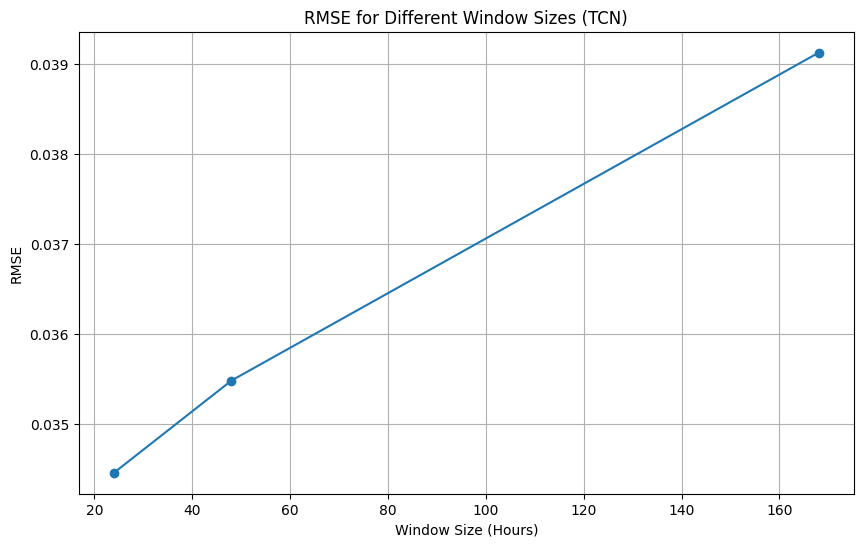

   window_size       MAE       MSE      RMSE
0           24  0.025824  0.001187  0.034455
1           48  0.026085  0.001259  0.035480
2          168  0.029189  0.001531  0.039127


In [11]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Assuming df_nsw_merge_temp_demand_forecast is loaded as df
df = df_nsw_merge_temp_demand_forecast

# Step 1: Add time-based features for seasonality (hour, day_of_week, month)
df['hour'] = df['DATETIME'].dt.hour
df['day_of_week'] = df['DATETIME'].dt.dayofweek
df['month'] = df['DATETIME'].dt.month

# Step 2: Normalize the target (TOTALDEMAND) and features (TEMPERATURE, FORECASTDEMAND, and time-based features)
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

# Select relevant features including seasonality features
features = ['TEMPERATURE', 'FORECASTDEMAND', 'hour', 'day_of_week', 'month']
target = 'TOTALDEMAND'

df[features] = scaler_features.fit_transform(df[features])
df[target] = scaler_target.fit_transform(df[[target]])

# Step 3: Create sequences for TCN input
def create_sequences(data, sequence_length):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, :-1])  # Use all columns except the target for X
        y.append(data[i, -1])  # Target is the last column (TOTALDEMAND)
    return np.array(X), np.array(y)

# Step 4: Experiment with different window sizes (e.g., 24 hours, 48 hours, 168 hours)
window_sizes = [24, 48, 168]
results = []

for window_size in window_sizes:
    print(f"Training with window size: {window_size}")
    
    # Convert the DataFrame to a NumPy array for creating sequences
    data = df[features + [target]].values
    
    # Create sequences for the current window size
    X, y = create_sequences(data, sequence_length=window_size)
    
    # Train-test split (80% train, 20% test)
    train_size = int(0.8 * len(X))
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Step 5: Build the TCN model
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))  # Dropout to prevent overfitting
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu'))  # Adding a second Conv1D layer
    model.add(Flatten())
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))  # Output layer

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)
    
    # Step 6: Make predictions
    y_pred = model.predict(X_test)

    # Step 7: Rescale the predictions and actual values back to their original scale
    y_pred_rescaled = scaler_target.inverse_transform(y_pred)
    y_test_rescaled = scaler_target.inverse_transform(y_test.reshape(-1, 1))

    # Step 8: Calculate evaluation metrics
    mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
    mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
    rmse = np.sqrt(mse)

    # Store results for the current window size
    results.append({
        'window_size': window_size,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    })

    # Print results for the current window size
    print(f"Results for window size {window_size}:")
    print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
    print("-" * 50)

# Step 9: Convert results to a DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Step 10: Plot RMSE for different window sizes
plt.figure(figsize=(10, 6))
plt.plot(results_df['window_size'], results_df['RMSE'], marker='o')
plt.title('RMSE for Different Window Sizes (TCN)')
plt.xlabel('Window Size (Hours)')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

# Display the results DataFrame
print(results_df)


### SVR timeseries

In [12]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Scale the data (both X and y) since SVR performs better with normalized data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Reshape y_train and y_test for scaling
y_train_reshaped = y_train.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# Flatten X_train and X_test from 3D to 2D, then scale
X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[1] * X_train.shape[2])
X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1] * X_test.shape[2])

X_train_scaled = scaler_X.fit_transform(X_train_flat)
X_test_scaled = scaler_X.transform(X_test_flat)

y_train_scaled = scaler_y.fit_transform(y_train_reshaped).ravel()
y_test_scaled = scaler_y.transform(y_test_reshaped).ravel()

# Step 2: Hyperparameter tuning using GridSearchCV for SVR
param_grid = {
    'C': [0.1, 1, 10, 100],         # Regularization parameter
    'epsilon': [0.01, 0.1, 0.2],    # Epsilon-insensitive loss function
    'gamma': ['scale', 'auto'],      # Kernel coefficient for 'rbf', 'poly', and 'sigmoid'
    'kernel': ['rbf', 'linear', 'poly']  # Try different kernels
}

svr = SVR()

grid_search = GridSearchCV(svr, param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_scaled)

# Get the best model from grid search
best_svr_model = grid_search.best_estimator_
print(f"Best Parameters from Grid Search: {grid_search.best_params_}")

# Step 3: Make predictions on the test set
y_pred_scaled = best_svr_model.predict(X_test_scaled)

# Rescale the predictions and actual values back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_rescaled = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

# Step 4: Calculate evaluation metrics
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)

# Print the evaluation metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

# Step 5: Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label='Actual Demand', color='blue')
plt.plot(y_pred_rescaled, label='Predicted Demand', color='red')
plt.xlabel('Time Step')
plt.ylabel('Electricity Demand')
plt.title('Actual vs Predicted Electricity Demand using SVR')
plt.legend()
plt.show()


Fitting 3 folds for each of 72 candidates, totalling 216 fits


: 